# Проект. Исследование стартапов

Автор: Земцова Ксения 

Дата: 20.03.2026

## Введение

Цель: провести исследование на исторических данных для финансовой компании, которая хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний.

Задачи:

1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести инжиниринг признаков:
  - изучить группы по срокам финансирования;
  - выделить средние и нишевые сегменты рынка.
4. Провести работу с выбросами и анализ:
  - проанализировать и пометить выбросы в каждом из сегментов;
  - определить границы рассматриваемого периода, отбрасываем аномалии;
  - провести анализ типов финансирования по объёму и популярности.
5. Провести анализ динамики:
  - изучить динамику предоставления финансирования по годам;
  - рассмотреть динамику размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов;
  - отследить годовую динамику доли возвращённых средств по типам финансирования.
6. Сформулировать выводы по проведённому анализу.

## Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### Вывод общей информации

Начнём с загрузки библиотек и датасетов `cb_investments.csv` и `cb_returns.csv`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `investments_df` и `returns_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные в переменные investments_df и returns_df
investments_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
returns_df = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

Выведем информацию, которая необходима для принятия решений о предобработке.

In [3]:
# Выводим первые строки датафрейма investments_df на экран
investments_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Выводим информацию о датафрейме investments_df
investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [5]:
# Выводим первые строки датафрейма returns_df на экран
returns_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [6]:
# Выводим информацию о датафрейме returns_df
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Сделаем вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметим другие особенности данных, которые обнаружены на этой стадии и на которые стоит обратить внимание при предобработке.

Выводы по датафрейму `investments_df`

Проблемы с типами данных
- `funding_total_usd` — хранится как object (строка), хотя должен быть числом для расчёта объёмов инвестиций.
- `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` — хранятся как object, хотя должны быть в формате datetime для анализа динамики по годам и выделения групп по срокам.
- `funding_rounds`, `founded_year` — хранятся как float64, хотя должны быть целыми числами (int).
- столбцы типов инвестиций (`seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market`, `product_crowdfunding`) — хранятся как float64 из-за пропусков, хотя должны быть либо целыми числами (суммы), либо заменены на 0 там, где инвестиций не было.
- cтолбцы раундов (`round_A`, `round_B`, `round_C`, `round_D`, `round_E`, `round_F`, `round_G`, `round_H`) — та же проблема: float64 вместо целых чисел с заменой пропусков на 0.
- можно оптимизировать данные до меньшего формата из float64 для более быстрой загрузки.

Проблемы с пропусками данных
- `participants` — пропущено 44% значений. Это делает анализ числа участников в раундах недостоверным без серьёзной обработки.
- `mid_funding_at` — пропущено 44% значений. Нельзя использовать для расчёта "среднего раунда" по всем компаниям.
- `state_code` — пропущено 45% значений. Проблема связана с неамериканскими компаниями, что исказит географический анализ.
- `founded_at`, `founded_year` — пропущено 29% значений. Это ограничит анализ сроков от основания до первого финансирования.
- `market`, `category_list` — пропущено ~16% значений. Часть компаний останется без рыночной классификации.
- `country_code`, `region`, `city` — пропущено ~19-20% значений. Осложнит региональный анализ.

Проблемы с содержимым
- `funding_total_usd` — значения могут содержать символы валют, запятые-разделители или текст вместо чисел ('--', 'null', 'undisclosed').
- `market`, `category_list` — могут содержать опечатки, разный регистр и лишние символы, что затруднит группировку сегментов.
- `category_list` — категории перечислены через |, может потребоваться разделение на отдельные признаки для анализа.

Проблемы с интерпретацией NaN в инвестиционных столбцах
- столбцы от `seed` до `round_H` — неясно, означает ли NaN "инвестиций этого типа не было" (тогда это 0) или "информация отсутствует" (тогда это пропуск). От этого решения зависит корректность расчёта долей возврата и объёмов.

Выводы по датафрейму `returns_df`

- можно оптимизировать данные до меньшего формата из float64 для более быстрой загрузки.
- столбец `year` в формате int64, возможно, нужно будет изменить на datetime.

### Предобработка данных

Проверим названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведем их к единому аккуратному стилю.

In [7]:
# Оптимизируем все числовые столбцы датафрейма investments_df
for col in investments_df.select_dtypes(include=['float64']).columns:
    investments_df[col] = pd.to_numeric(investments_df[col], downcast='float')

# Проверяем результат
investments_df.dtypes

name                     object
homepage_url             object
category_list            object
 market                  object
 funding_total_usd       object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float32
participants            float32
founded_at               object
founded_month            object
founded_quarter          object
founded_year            float32
first_funding_at         object
mid_funding_at           object
last_funding_at          object
seed                    float32
venture                 float32
equity_crowdfunding     float32
undisclosed             float32
convertible_note        float32
debt_financing          float32
angel                   float32
grant                   float32
private_equity          float32
post_ipo_equity         float32
post_ipo_debt           float32
secondary_market        float32
product_

In [8]:
# Оптимизируем все числовые столбцы датафрейма returns_df
for col in returns_df.select_dtypes(include=['float64']).columns:
    returns_df[col] = pd.to_numeric(returns_df[col], downcast='float')

# Проверяем результат
returns_df.dtypes

year                      int64
seed                    float32
venture                 float32
equity_crowdfunding     float32
undisclosed             float32
convertible_note        float32
debt_financing          float32
angel                   float32
grant                   float32
private_equity          float32
post_ipo_equity         float32
post_ipo_debt           float32
secondary_market        float32
product_crowdfunding    float32
dtype: object

In [9]:
# Убираем пробелы в названиях столбцов датафрейма investments_df
investments_df.columns = investments_df.columns.str.strip()

# Потом переименовываем нужные столбцы
investments_df = investments_df.rename(columns={
    'funding_rounds': 'rounds_count',
    'participants': 'participants_count',
    'founded_at': 'founded_date',
    'first_funding_at': 'first_funding_date',
    'mid_funding_at': 'mid_funding_date',
    'last_funding_at': 'last_funding_date',
    'round_A': 'round_a',
    'round_B': 'round_b',
    'round_C': 'round_c',
    'round_D': 'round_d',
    'round_E': 'round_e',
    'round_F': 'round_f',
    'round_G': 'round_g',
    'round_H': 'round_h'
})

# Проверяем финальный результат
investments_df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'rounds_count', 'participants_count', 'founded_date', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_date',
       'mid_funding_date', 'last_funding_date', 'seed', 'venture',
       'equity_crowdfunding', 'undisclosed', 'convertible_note',
       'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
       'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_a',
       'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g',
       'round_h'],
      dtype='object')

In [10]:
# Убираем пробелы в названиях столбцов датафрейма returns_df
returns_df.columns = returns_df.columns.str.strip()

# Проверяем результат
returns_df.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

Уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

In [11]:
# Уберем лишние символы, разделения и преобразуем столбец funding_total_usd
investments_df['funding_total_usd'] = (investments_df['funding_total_usd'].astype(str).str.replace(r'[,$]', '', regex=True).str.strip().pipe(pd.to_numeric, errors='coerce'))

Обработаем типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [12]:
# Список столбцов с датами в датафрейме investments_df
date_columns = [
    'founded_date', 
    'first_funding_date', 
    'mid_funding_date', 
    'last_funding_date'
]

# Преобразуем каждый столбец в datetime
for col in date_columns:
    investments_df[col] = pd.to_datetime(investments_df[col], errors='coerce')

In [13]:
# Преобразуем год в формат datetime из датафрейма returns_df
returns_df['year'] = pd.to_datetime(returns_df['year'], format='%Y')

В датасете `cb_returns` сделаем столбец `year` индексом всего датасета.

In [14]:
# Устанавливаем столбец year как индекс
returns_df = returns_df.set_index('year')

Обработаем текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполним заглушками там, где это понадобится.

In [15]:
# Список текстовых столбцов в первом датафрейме
text_columns = [
    'name', 'homepage_url', 'category_list', 'market', 'status',
    'country_code', 'state_code', 'region', 'city'
]

# Заполняем пропуски заглушками
for col in text_columns:
    if col in investments_df.columns:
        # Для разных столбцов используем разные заглушки
        if col == 'name':
            investments_df[col] = investments_df[col].fillna('Unknown Company')
        elif col == 'homepage_url':
            investments_df[col] = investments_df[col].fillna('no_url')
        elif col in ['category_list', 'market']:
            investments_df[col] = investments_df[col].fillna('Unknown Category')
        elif col == 'status':
            investments_df[col] = investments_df[col].fillna('Unknown Status')
        elif col in ['country_code', 'state_code', 'region', 'city']:
            investments_df[col] = investments_df[col].fillna('Unknown')
        
        # Приводим к нижнему регистру для единообразия
        investments_df[col] = investments_df[col].str.lower()
        
        # Убираем лишние пробелы
        investments_df[col] = investments_df[col].str.strip()

# Проверяем результат
for col in text_columns:
    if col in investments_df.columns:
        print(f"{col}: {investments_df[col].isna().sum()} пропусков")
        print(f"Уникальные значения: {investments_df[col].nunique()}\n")

name: 0 пропусков
Уникальные значения: 49332

homepage_url: 0 пропусков
Уникальные значения: 45847

category_list: 0 пропусков
Уникальные значения: 16676

market: 0 пропусков
Уникальные значения: 440

status: 0 пропусков
Уникальные значения: 4

country_code: 0 пропусков
Уникальные значения: 116

state_code: 0 пропусков
Уникальные значения: 62

region: 0 пропусков
Уникальные значения: 1090

city: 0 пропусков
Уникальные значения: 4189



Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [16]:
investments_df = investments_df.drop_duplicates()
investments_df = investments_df.dropna(subset=['funding_total_usd'])

print(f"Финальный размер: {investments_df.shape}")

Финальный размер: (40907, 40)


Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

Оценим размер оставшихся пропусков в столбце.

In [17]:
print(f"Пропусков до: {investments_df['mid_funding_date'].isna().sum()}")

investments_df['mid_funding_date'] = investments_df['mid_funding_date'].fillna(
    investments_df['first_funding_date'] + 
    (investments_df['last_funding_date'] - investments_df['first_funding_date']) / 2
)

print(f"Пропусков после: {investments_df['mid_funding_date'].isna().sum()}")

Пропусков до: 13676
Пропусков после: 1


In [18]:
# Начальное количество строк
initial_rows = 54294  

# Текущее количество строк после всей очистки
current_rows = len(investments_df)
rows_removed = initial_rows - current_rows
removed_percent = (rows_removed / initial_rows) * 100

print("Оценка полноты данных")
print(f"Начальное количество строк: {initial_rows}")
print(f"Текущее количество строк: {current_rows}")
print(f"Удалено строк: {rows_removed}")
print(f"Процент удаленных данных: {removed_percent:.1f}%")
print(f"Осталось данных: {100 - removed_percent:.1f}%\n")

# Проверяем пропуски в ключевых столбцах после очистки
print("Пропуски в ключевых столбцах")
key_columns = ['funding_total_usd', 'first_funding_date', 'last_funding_date','category_list','market','status']

for col in key_columns:
    if col in investments_df.columns:
        nulls = investments_df[col].isna().sum()
        nulls_percent = (nulls / current_rows) * 100
        print(f"{col}: {nulls} пропусков ({nulls_percent:.1f}%)")

# Проверяем наличие данных по годам
print("\nДиапазон дат")
if 'first_funding_date' in investments_df.columns:
    min_year = investments_df['first_funding_date'].dt.year.min()
    max_year = investments_df['first_funding_date'].dt.year.max()
    print(f"Период финансирования: {min_year} - {max_year}")

Оценка полноты данных
Начальное количество строк: 54294
Текущее количество строк: 40907
Удалено строк: 13387
Процент удаленных данных: 24.7%
Осталось данных: 75.3%

Пропуски в ключевых столбцах
funding_total_usd: 0 пропусков (0.0%)
first_funding_date: 2 пропусков (0.0%)
last_funding_date: 0 пропусков (0.0%)
category_list: 0 пропусков (0.0%)
market: 0 пропусков (0.0%)
status: 0 пропусков (0.0%)

Диапазон дат
Период финансирования: 1921.0 - 2014.0


В результате предобработки из исходного датасета, содержавшего 54 294 записи, было удалено 13 387 строк, что составляет 24,7% от общего объёма данных. Таким образом, для дальнейшего анализа осталось 40 907 записей (75,3% от исходного объёма).

Потеря почти четверти данных — это значительный, но допустимый объём, учитывая, что удалялись строки, не содержащие информации о финансировании (отсутствовала общая сумма инвестиций и данные по всем типам финансирования). Оставшихся 40 тысяч записей достаточно для построения статистически значимых выводов.

Ключевое преимущество очищенного датасета — в ключевых столбцах практически отсутствуют пропуски:
- `funding_total_usd` — 0% пропусков (полные данные об объёмах инвестиций)
- `first_funding_date`, `last_funding_date` — 0% пропусков (возможен полноценный временной анализ)
- `category_list`, `market`, `status` — 0% пропусков (все компании имеют категорию, рынок и статус)

Временной охват данных составляет 1921–2014 годы, что полностью соответствует условию проекта — анализ до 2015 года.

## Инжиниринг признаков

### Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

In [19]:
print("РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ\n")

investments_df['days_diff'] = (investments_df['last_funding_date'] - investments_df['first_funding_date']).dt.days

investments_df['funding_term_group'] = 'Срок финансирования более года'
investments_df.loc[investments_df['rounds_count'] == 1, 'funding_term_group'] = 'Единичное финансирование'
investments_df.loc[
    (investments_df['rounds_count'] > 1) & 
    (investments_df['days_diff'] <= 365), 
    'funding_term_group'
] = 'Срок финансирования до года'

# Удаляем только временный столбец, оставляя funding_term_group
investments_df = investments_df.drop(columns=['days_diff'])

print(investments_df['funding_term_group'].value_counts())
print("\nПроценты:")
print((investments_df['funding_term_group'].value_counts() / len(investments_df) * 100).round(1))

РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ

Единичное финансирование          24113
Срок финансирования более года    12293
Срок финансирования до года        4501
Name: funding_term_group, dtype: int64

Проценты:
Единичное финансирование          58.9
Срок финансирования более года    30.1
Срок финансирования до года       11.0
Name: funding_term_group, dtype: float64


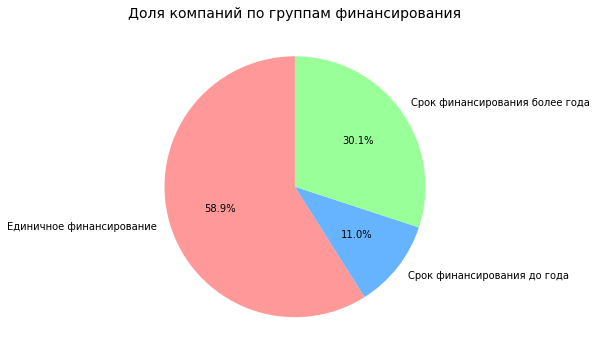

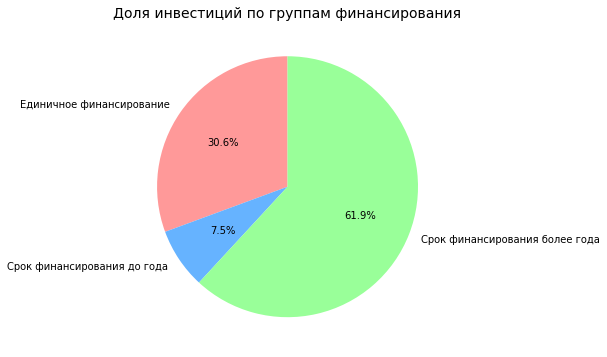


Количество компаний:
Единичное финансирование          24113
Срок финансирования до года        4501
Срок финансирования более года    12293
Name: funding_term_group, dtype: int64

Объем инвестиций ($):
funding_term_group
Единичное финансирование          1.993044e+11
Срок финансирования до года       4.888598e+10
Срок финансирования более года    4.027433e+11
Name: funding_total_usd, dtype: float64


In [20]:
# Считаем статистику по группам
group_companies = investments_df['funding_term_group'].value_counts()
group_investment = investments_df.groupby('funding_term_group')['funding_total_usd'].sum()

# Сортируем в одинаковом порядке
groups = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']
group_companies = group_companies.reindex(groups)
group_investment = group_investment.reindex(groups)

# Цвета для групп
colors = ['#ff9999', '#66b3ff', '#99ff99']

# ГРАФИК 1: Доля компаний
plt.figure(figsize=(8, 6))
plt.pie(group_companies, labels=group_companies.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
plt.title('Доля компаний по группам финансирования', fontsize=14)
plt.show()

# ГРАФИК 2: Доля инвестиций
plt.figure(figsize=(8, 6))
plt.pie(group_investment, labels=group_investment.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
plt.title('Доля инвестиций по группам финансирования', fontsize=14)
plt.show()

# Для проверки выведем цифры
print("\nКоличество компаний:")
print(group_companies)
print("\nОбъем инвестиций ($):")
print(group_investment)

Заметно, что больше всего компаний получили единичное финансировние — 24113 компаний или 59% от общего числа. 30% компаний имеют срок финансирования более года и 11% — 
срок финансирования до года.

Однако в денежном выражении распределение категорий выглядит иначе. 62% инвестиций в денежном выражении пришлось на срок финансирования более года, 31% — единичное финансирование и 7% — до года.

Такие наблюдения объяснимы. Почти все компании хотя бы раз получали финасирование, поэтому вариант единичного финасирования самый популярный среди числа компаний. В денежном выражении накопленным итогом самая большая доля у компании с более длительным сроком финансирования.

### Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [21]:
# Считаем частоту встречаемости каждого сегмента
market_counts = investments_df['market'].value_counts()
print(f"Всего уникальных сегментов: {len(market_counts)}")
print(f"Топ-10 самых популярных сегментов:")
print(market_counts.head(10))
print()

# Классифицируем сегменты по частоте
mass_markets = market_counts[market_counts > 120].index.tolist()
medium_markets = market_counts[(market_counts >= 35) & (market_counts <= 120)].index.tolist()
niche_markets = market_counts[market_counts < 35].index.tolist()

# Считаем количество сегментов в каждой категории
print("КЛАССИФИКАЦИЯ СЕГМЕНТОВ")
print(f"Массовые сегменты (>120 компаний): {len(mass_markets)} сегментов")
print(f"Средние сегменты (35-120 компаний): {len(medium_markets)} сегментов")
print(f"Нишевые сегменты (<35 компаний): {len(niche_markets)} сегментов")

# Добавляем столбец с категорией сегмента в датафрейм
def classify_market(market):
    count = market_counts[market]
    if count > 120:
        return 'массовый'
    elif count >= 35:
        return 'средний'
    else:
        return 'нишевой'

investments_df['market_segment'] = investments_df['market'].apply(classify_market)

# Проверяем распределение компаний по категориям
print("\nРАСПРЕДЕЛЕНИЕ КОМПАНИЙ ПО КАТЕГОРИЯМ СЕГМЕНТОВ")
company_distribution = investments_df['market_segment'].value_counts()
print(company_distribution)
print("\nВ процентах:")
print((company_distribution / len(investments_df) * 100).round(1))

# Смотрим примеры из каждой категории
print("\nПРИМЕРЫ СЕГМЕНТОВ")
print(f"Массовый сегмент (примеры): {mass_markets[:5]}")
print(f"Средний сегмент (примеры): {medium_markets[:5]}")
print(f"Нишевый сегмент (примеры): {niche_markets[:5]}")

Всего уникальных сегментов: 395
Топ-10 самых популярных сегментов:
software               4812
biotechnology          3590
unknown category       2503
mobile                 2344
e-commerce             1866
curated web            1693
enterprise software    1381
health care            1185
clean technology       1180
games                  1117
Name: market, dtype: int64

КЛАССИФИКАЦИЯ СЕГМЕНТОВ
Массовые сегменты (>120 компаний): 49 сегментов
Средние сегменты (35-120 компаний): 57 сегментов
Нишевые сегменты (<35 компаний): 289 сегментов

РАСПРЕДЕЛЕНИЕ КОМПАНИЙ ПО КАТЕГОРИЯМ СЕГМЕНТОВ
массовый    36236
средний      3841
нишевой       830
Name: market_segment, dtype: int64

В процентах:
массовый    88.6
средний      9.4
нишевой      2.0
Name: market_segment, dtype: float64

ПРИМЕРЫ СЕГМЕНТОВ
Массовый сегмент (примеры): ['software', 'biotechnology', 'unknown category', 'mobile', 'e-commerce']
Средний сегмент (примеры): ['sales and marketing', 'financial services', 'medical devices', 'medi

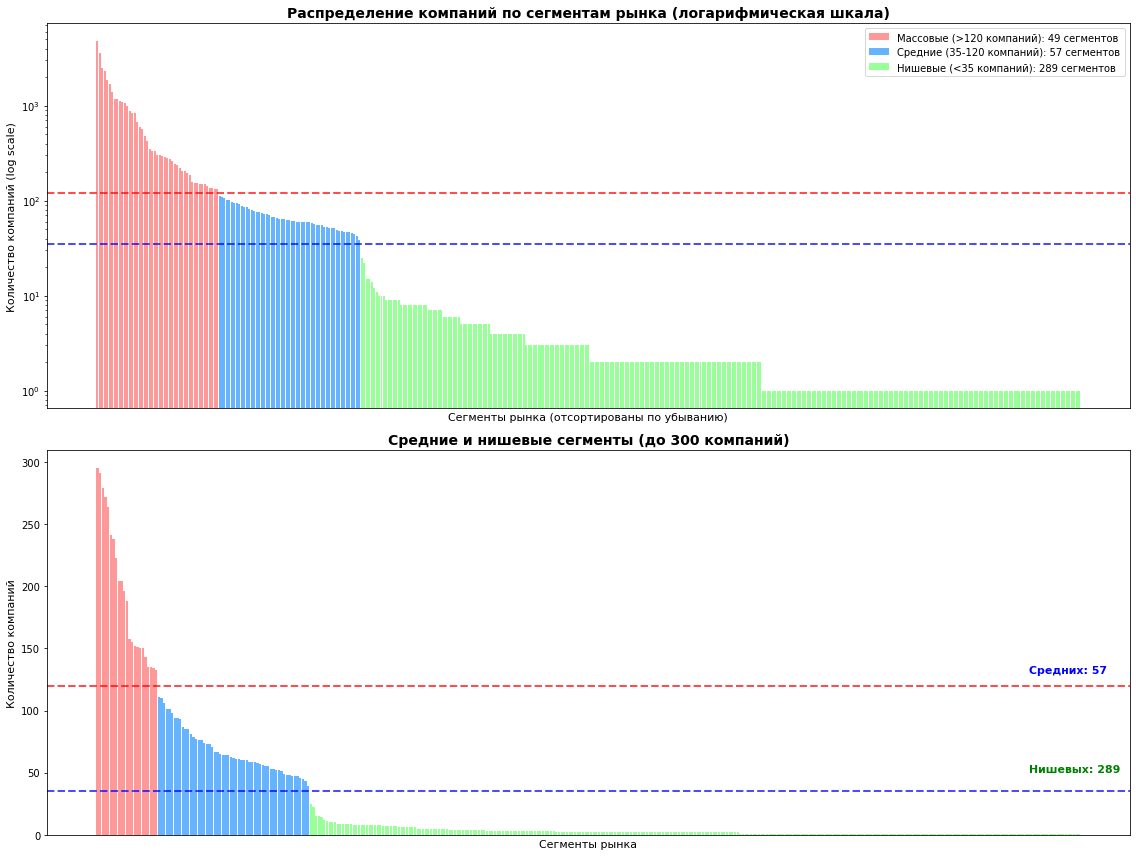

СТАТИСТИКА РАСПРЕДЕЛЕНИЯ
Максимальное количество компаний в сегменте: 4812
Медианное количество: 3
Среднее количество: 103.6
Минимальное количество: 1

РАСПРЕДЕЛЕНИЕ ПО ДИАПАЗОНАМ
Сегментов с 1 компанией: 128
Сегментов с 2-10 компаниями: 154
Сегментов с 11-34 компаниями: 7
Сегментов с 35-120 компаниями: 57
Сегментов с >120 компаниями: 49


In [22]:
# Сортируем сегменты по убыванию количества компаний
market_counts_sorted = market_counts.sort_values(ascending=False)

# Создаем список цветов для каждого сегмента
colors = []
for segment in market_counts_sorted.index:
    count = market_counts_sorted[segment]
    if count > 120:
        colors.append('#ff9999')  # красный - массовые
    elif count >= 35:
        colors.append('#66b3ff')  # синий - средние
    else:
        colors.append('#99ff99')  # зеленый - нишевые

# Создадим 2 графика: общий и срез по нишевым, средним
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# График 1: Общий с логарифмической шкалой
ax1.bar(range(len(market_counts_sorted)), market_counts_sorted.values, color=colors)
ax1.axhline(y=120, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.axhline(y=35, color='blue', linestyle='--', linewidth=2, alpha=0.7)

# Логарифмическая шкала для лучшей читаемости
ax1.set_yscale('log')
ax1.set_title('Распределение компаний по сегментам рынка (логарифмическая шкала)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Сегменты рынка (отсортированы по убыванию)', fontsize=11)
ax1.set_ylabel('Количество компаний (log scale)', fontsize=11)
ax1.set_xticks([])

# Легенда для первого графика
ax1.legend(handles=[
    plt.Rectangle((0,0),1,1, facecolor='#ff9999', label=f'Массовые (>120 компаний): {len(mass_markets)} сегментов'),
    plt.Rectangle((0,0),1,1, facecolor='#66b3ff', label=f'Средние (35-120 компаний): {len(medium_markets)} сегментов'),
    plt.Rectangle((0,0),1,1, facecolor='#99ff99', label=f'Нишевые (<35 компаний): {len(niche_markets)} сегментов')
], loc='upper right')

# График 2: Только средние и нишевые (до 200 компаний для наглядности)
# Отбираем сегменты с количеством компаний до 300 (чтобы захватить часть массовых и все средние/нишевые)
filtered_counts = market_counts_sorted[market_counts_sorted.values <= 300]

# Цвета для отфильтрованных данных
filtered_colors = []
for segment in filtered_counts.index:
    count = filtered_counts[segment]
    if count > 120:
        filtered_colors.append('#ff9999')  # красный - массовые (верхняя часть средних)
    elif count >= 35:
        filtered_colors.append('#66b3ff')  # синий - средние
    else:
        filtered_colors.append('#99ff99')  # зеленый - нишевые

# Рисуем второй график
ax2.bar(range(len(filtered_counts)), filtered_counts.values, color=filtered_colors)
ax2.axhline(y=120, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax2.axhline(y=35, color='blue', linestyle='--', linewidth=2, alpha=0.7)

ax2.set_title('Средние и нишевые сегменты (до 300 компаний)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Сегменты рынка', fontsize=11)
ax2.set_ylabel('Количество компаний', fontsize=11)
ax2.set_xticks([])

# Добавляем аннотации с примерами
ax2.text(len(filtered_counts) - 20, 130, f'Средних: {len(medium_markets)}', 
         fontsize=11, color='blue', fontweight='bold')
ax2.text(len(filtered_counts) - 20, 50, f'Нишевых: {len(niche_markets)}', 
         fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

# Дополнительно: статистика для понимания масштабов
print("СТАТИСТИКА РАСПРЕДЕЛЕНИЯ")
print(f"Максимальное количество компаний в сегменте: {market_counts.max()}")
print(f"Медианное количество: {market_counts.median():.0f}")
print(f"Среднее количество: {market_counts.mean():.1f}")
print(f"Минимальное количество: {market_counts.min()}")

# Сколько сегментов попадает в разные диапазоны
print("\nРАСПРЕДЕЛЕНИЕ ПО ДИАПАЗОНАМ")
print(f"Сегментов с 1 компанией: {(market_counts == 1).sum()}")
print(f"Сегментов с 2-10 компаниями: {((market_counts >= 2) & (market_counts <= 10)).sum()}")
print(f"Сегментов с 11-34 компаниями: {((market_counts >= 11) & (market_counts <= 34)).sum()}")
print(f"Сегментов с 35-120 компаниями: {len(medium_markets)}")
print(f"Сегментов с >120 компаниями: {len(mass_markets)}")

На основе анализа сегментов рынка можно сделать следующие выводы:

1. **Концентрация рынка**. Рынок стартапов сильно сконцентрирован: всего 49 массовых сегментов (12% от общего числа) охватывают 88,6% всех компаний (36 236 из 40 907). Это говорит о том, что инвестиционная активность сосредоточена в относительно небольшом количестве популярных направлений.

2. **Длинный хвост нишевых сегментов**. Несмотря на малое количество компаний в каждом, нишевых сегментов большинство — 289 (73% от всех сегментов). Однако на них приходится лишь 2% компаний. Это подтверждает гипотезу о «длинном хвосте»: существует множество узких направлений с небольшим числом игроков.

3. **Средние сегменты**. Сегментов со средним числом компаний (35–120) насчитывается 57 (14% от всех), и они занимают промежуточное положение, охватывая 9,4% компаний.

4. **Лидеры рынка**. Наиболее популярные сегменты — software, biotechnology, mobile, e-commerce. Именно в этих направлениях сосредоточена основная масса стартапов и, предположительно, основной объём инвестиций.

5. **Сильная асимметрия распределения**. Среднее количество компаний в сегменте составляет 103,6, но медианное значение — всего 3. Это указывает на то, что распределение сильно смещено в сторону малых значений: большинство сегментов содержат лишь несколько компаний, а крупные сегменты-лидеры создают высокое среднее значение.

6. **Преобладание сегментов с минимальным числом компаний**. 128 сегментов (почти треть от общего числа) содержат всего по одной компании. Это говорит о высокой фрагментированности рынка: многие направления представлены единичными стартапами, что может свидетельствовать либо о зарождающихся нишах, либо об экспериментальных проектах.

7. **Разрыв между средними и массовыми сегментами**. Количество сегментов с 11–34 компаниями минимально — всего 7. Наблюдается резкий переход от микрониш (1–10 компаний) сразу к средним сегментам (35–120 компаний). Это говорит о том, что сегменты либо остаются очень маленькими, либо, преодолев порог в 35 компаний, быстро переходят в категорию средних.

Таким образом, для дальнейшего анализа целесообразно выделить массовые сегменты как основные драйверы рынка,  а средние и нишевые объединить в обобщённые группы для упрощения модели без потери значимой информации.

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполним с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не будем — они объединяются в два общих сегмента.


In [23]:
# Считаем частоту встречаемости каждого сегмента
market_counts = investments_df['market'].value_counts()

# Создаем функцию для замены
def categorize_market(market):
    count = market_counts[market]
    if count > 120:
        return market  # оставляем название массового сегмента
    elif count >= 35:
        return 'mid'  # средние сегменты
    else:
        return 'niche'  # нишевые сегменты

# Применяем функцию к столбцу market
investments_df['market'] = investments_df['market'].apply(categorize_market)

## Работа с выбросами и анализ

### Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажем интервал, в котором лежат типичные значения.

СТАТИСТИКА funding_total_usd

count    3.558800e+04
mean     4.534501e+06
std      8.033385e+06
min      1.000000e+00
25%      2.500000e+05
50%      1.310000e+06
75%      5.000000e+06
max      7.498919e+07
Name: funding_total_usd, dtype: float64

25% компаний получили меньше: $0.25 млн
50% компаний получили меньше: $1.31 млн (типичное значение — медиана)
75% компаний получили меньше: $5.00 млн


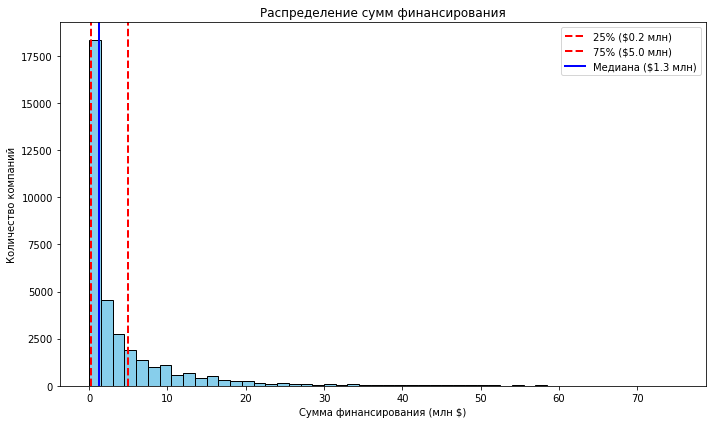

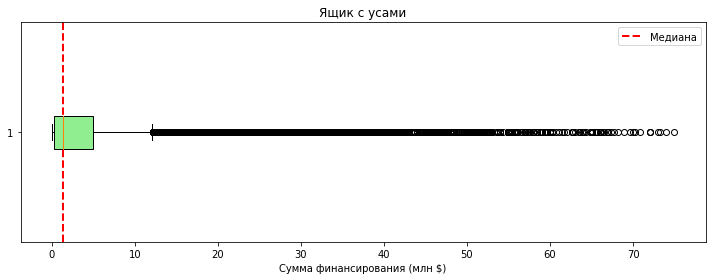

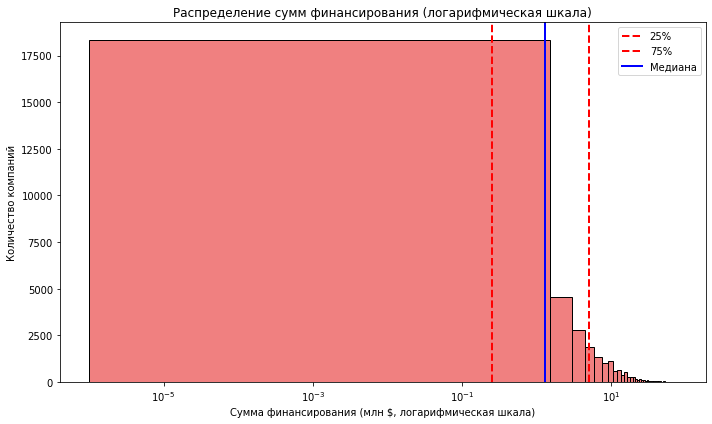


ТИПИЧНЫЙ РАЗМЕР ФИНАНСИРОВАНИЯ
Типичные значения (от 25% до 75% компаний):
от $0.25 млн до $5.00 млн

В этом интервале находится 18290 компаний
Это 51.4% от всех компаний


In [40]:
# Базовая статистика
print("СТАТИСТИКА funding_total_usd\n")
describe_stats = investments_df['funding_total_usd'].describe()
print(describe_stats)

# Квартили
q1 = describe_stats['25%']
q2 = describe_stats['50%']  # медиана - типичное значение
q3 = describe_stats['75%']

print(f"\n25% компаний получили меньше: ${q1/1e6:.2f} млн")
print(f"50% компаний получили меньше: ${q2/1e6:.2f} млн (типичное значение — медиана)")
print(f"75% компаний получили меньше: ${q3/1e6:.2f} млн")

# График 1: Гистограмма (обычная шкала)
plt.figure(figsize=(10, 6))
plt.hist(investments_df['funding_total_usd']/1e6, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Сумма финансирования (млн $)')
plt.ylabel('Количество компаний')
plt.title('Распределение сумм финансирования')
# Добавляем вертикальные линии для квантилей
plt.axvline(q1/1e6, color='red', linestyle='--', linewidth=2, label=f'25% (${q1/1e6:.1f} млн)')
plt.axvline(q3/1e6, color='red', linestyle='--', linewidth=2, label=f'75% (${q3/1e6:.1f} млн)')
plt.axvline(investments_df['funding_total_usd'].median()/1e6, color='blue', linestyle='-', linewidth=2, label=f'Медиана (${investments_df["funding_total_usd"].median()/1e6:.1f} млн)')
plt.legend()
plt.tight_layout()
plt.show()

# График 2: Ящик с усами (boxplot)
plt.figure(figsize=(10, 4))
box_data = investments_df['funding_total_usd']/1e6
plt.boxplot(box_data, vert=False, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.xlabel('Сумма финансирования (млн $)')
plt.title('Ящик с усами')
# Добавляем вертикальную линию для медианы
plt.axvline(investments_df['funding_total_usd'].median()/1e6, color='red', linestyle='--', linewidth=2, label=f'Медиана')
plt.legend()
plt.tight_layout()
plt.show()

# График 3: Логарифмическая шкала
plt.figure(figsize=(10, 6))
plt.hist(investments_df['funding_total_usd']/1e6, bins=50, color='lightcoral', edgecolor='black')
plt.xscale('log')
plt.xlabel('Сумма финансирования (млн $, логарифмическая шкала)')
plt.ylabel('Количество компаний')
plt.title('Распределение сумм финансирования (логарифмическая шкала)')
plt.axvline(q1/1e6, color='red', linestyle='--', linewidth=2, label=f'25%')
plt.axvline(q3/1e6, color='red', linestyle='--', linewidth=2, label=f'75%')
plt.axvline(investments_df['funding_total_usd'].median()/1e6, color='blue', linestyle='-', linewidth=2, label=f'Медиана')
plt.legend()
plt.tight_layout()
plt.show()

# Интервал типичных значений
print("\nТИПИЧНЫЙ РАЗМЕР ФИНАНСИРОВАНИЯ")
print(f"Типичные значения (от 25% до 75% компаний):")
print(f"от ${q1/1e6:.2f} млн до ${q3/1e6:.2f} млн")

typical_count = len(investments_df[(investments_df['funding_total_usd'] >= q1) & 
                                   (investments_df['funding_total_usd'] <= q3)])
print(f"\nВ этом интервале находится {typical_count} компаний")
print(f"Это {typical_count/len(investments_df)*100:.1f}% от всех компаний")

Определим компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. 

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

ОБЩАЯ СТАТИСТИКА ВЫБРОСОВ
Всего компаний с аномальным финансированием: 5244
Доля аномальных компаний: 12.8%

РАСПРЕДЕЛЕНИЕ ВЫБРОСОВ ПО СЕГМЕНТАМ
                      count  sum  outlier_percent
market                                           
real estate             279   48             17.2
entertainment           150   25             16.7
consulting              349   58             16.6
search                  291   48             16.5
cloud computing         152   25             16.4
photography             204   33             16.2
saas                    272   44             16.2
video                   188   30             16.0
technology              238   38             16.0
niche                   830  132             15.9
travel                  330   51             15.5
internet                241   37             15.4
networking              143   22             15.4
big data                150   23             15.3
marketplaces            196   30             15.3
unkno

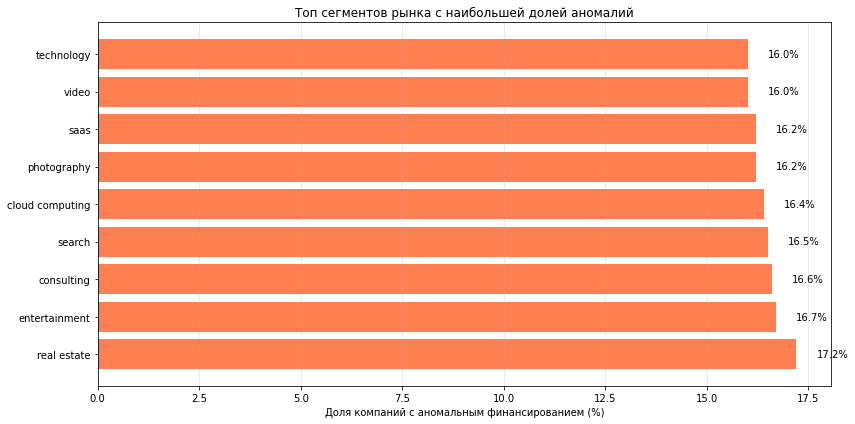

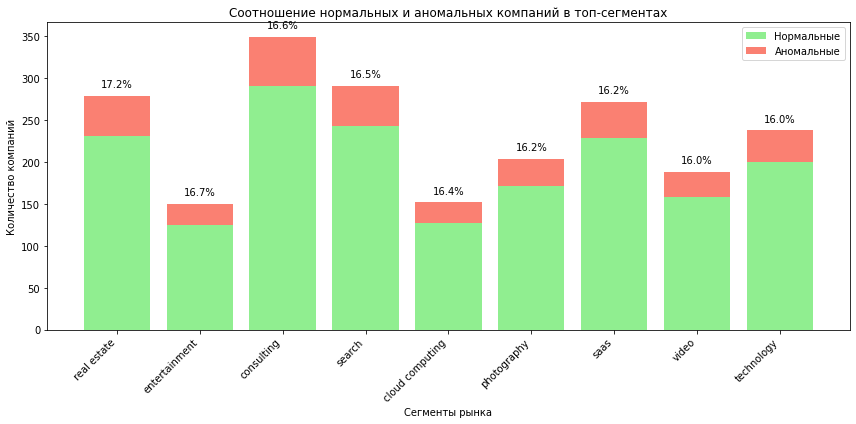

In [25]:
# Создаем функцию для определения выбросов по методу IQR
def find_outliers_by_group(group):
    q1 = group['funding_total_usd'].quantile(0.25)
    q3 = group['funding_total_usd'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    group['is_outlier'] = (group['funding_total_usd'] < lower_bound) | (group['funding_total_usd'] > upper_bound)
    return group

# Применяем функцию к каждому сегменту отдельно
investments_df = investments_df.groupby('market', group_keys=False).apply(find_outliers_by_group)

# Смотрим общую статистику по выбросам
print("ОБЩАЯ СТАТИСТИКА ВЫБРОСОВ")
total_outliers = investments_df['is_outlier'].sum()
print(f"Всего компаний с аномальным финансированием: {total_outliers}")
print(f"Доля аномальных компаний: {total_outliers/len(investments_df)*100:.1f}%")

# Распределение выбросов по сегментам
print("\nРАСПРЕДЕЛЕНИЕ ВЫБРОСОВ ПО СЕГМЕНТАМ")
outlier_by_segment = investments_df.groupby('market')['is_outlier'].agg(['count', 'sum'])
outlier_by_segment['outlier_percent'] = (outlier_by_segment['sum'] / outlier_by_segment['count'] * 100).round(1)
outlier_by_segment = outlier_by_segment.sort_values('outlier_percent', ascending=False)

print(outlier_by_segment)

# Топ-10 сегментов с наибольшей долей аномалий
print("\n=== ТОП-10 СЕГМЕНТОВ С НАИБОЛЬШЕЙ ДОЛЕЙ АНОМАЛЬНОГО ФИНАНСИРОВАНИЯ ===")
top_outliers = outlier_by_segment.head(10)
print(top_outliers)

# Отдельно посмотрим на mid и niche сегменты
print("\nАНОМАЛИИ В ОБЪЕДИНЕННЫХ СЕГМЕНТАХ")
for segment in ['mid', 'niche']:
    if segment in outlier_by_segment.index:
        data = outlier_by_segment.loc[segment]
        print(f"{segment}: {data['sum']} компаний из {data['count']} ({data['outlier_percent']}%)")

# Визуализация топ-сегментов с аномалиями
plt.figure(figsize=(12, 6))

# Берем топ-10 сегментов с самой высокой долей выбросов
plot_data = top_outliers.copy()

# Убираем mid и niche из графика, если они там есть (чтобы не смешивать)
plot_data = plot_data[~plot_data.index.isin(['mid', 'niche'])]

plt.barh(range(len(plot_data)), plot_data['outlier_percent'].values, color='coral')
plt.yticks(range(len(plot_data)), plot_data.index)
plt.xlabel('Доля компаний с аномальным финансированием (%)')
plt.title('Топ сегментов рынка с наибольшей долей аномалий')
plt.grid(axis='x', alpha=0.3)

# Добавляем значения
for i, (idx, row) in enumerate(plot_data.iterrows()):
    plt.text(row['outlier_percent'] + 0.5, i, f"{row['outlier_percent']}%", va='center')

plt.tight_layout()
plt.show()

# Сравнение количества нормальных и аномальных компаний в топ-сегментах
plt.figure(figsize=(12, 6))

x = range(len(plot_data))
normal = plot_data['count'] - plot_data['sum']
outliers = plot_data['sum']

plt.bar(x, normal, label='Нормальные', color='lightgreen')
plt.bar(x, outliers, bottom=normal, label='Аномальные', color='salmon')
plt.xlabel('Сегменты рынка')
plt.ylabel('Количество компаний')
plt.title('Соотношение нормальных и аномальных компаний в топ-сегментах')
plt.xticks(x, plot_data.index, rotation=45, ha='right')
plt.legend()

# Добавляем проценты аномалий над столбцами
for i, (idx, row) in enumerate(plot_data.iterrows()):
    plt.text(i, row['count'] + 10, f"{row['outlier_percent']}%", ha='center')

plt.tight_layout()
plt.show()

### Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что предоставлены полные данные за 2014 год. Затем исключим из датасета компании, которые ранее посчитали получившими аномальное финансирование.

Когда исключили аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [26]:
# ПРОВЕРКА 2014 ГОДА
print("ПРОВЕРКА ДАННЫХ ЗА 2014 ГОД\n")

# Считаем компании по годам последнего финансирования
years = investments_df['last_funding_date'].dt.year
year_counts = years.value_counts().sort_index()
print("Компаний по годам:")
print(year_counts)

# Проверяем 2014 год
if 2014 in year_counts.index:
    count_2014 = year_counts[2014]
    count_2013 = year_counts.get(2013, 0)
    
    print(f"\nКомпаний в 2014: {count_2014}")
    print(f"Компаний в 2013: {count_2013}")
    
    if count_2013 > 0:
        ratio = count_2014 / count_2013
        if ratio > 0.7:
            print(f"Данные за 2014 год выглядят нормально ({ratio*100:.1f}% от 2013)")
        else:
            print(f"Возможно, данные за 2014 год неполные ({ratio*100:.1f}% от 2013)")
else:
    print("В данных нет 2014 года!")

# Проверяем последний год
last_year = year_counts.index.max()
if last_year == 2014:
    print(f"Последний год в данных: {last_year}")
else:
    print(f"Последний год в данных: {last_year}, а должен быть 2014")

# Удалим аномальные компании
print("\nУДАЛЕНИЕ АНОМАЛИЙ")

if 'is_outlier' in investments_df.columns:
    before = len(investments_df)
    outliers = investments_df['is_outlier'].sum()
    
    print(f"Всего компаний: {before}")
    print(f"Аномальных компаний: {outliers} ({outliers/before*100:.1f}%)")
    
    # Удаляем аномалии
    investments_df = investments_df[investments_df['is_outlier'] == False]
    
    after = len(investments_df)
    print(f"Осталось компаний после удаления: {after}")
    print(f"Удалено: {before - after}")
else:
    print("Сначала нужно создать столбец is_outlier с аномалиями")

ПРОВЕРКА ДАННЫХ ЗА 2014 ГОД

Компаний по годам:
1921        1
1960        1
1979        1
1982        3
1983        1
1984        1
1985        3
1987        2
1989        1
1990        1
1992        3
1993        1
1994        5
1995        2
1996        1
1997        4
1998        8
1999       26
2000       63
2001       50
2002       47
2003       53
2004       86
2005      646
2006     1007
2007     1332
2008     1700
2009     2441
2010     3410
2011     4109
2012     5296
2013     8687
2014    11915
Name: last_funding_date, dtype: int64

Компаний в 2014: 11915
Компаний в 2013: 8687
Данные за 2014 год выглядят нормально (137.2% от 2013)
Последний год в данных: 2014

УДАЛЕНИЕ АНОМАЛИЙ
Всего компаний: 40907
Аномальных компаний: 5244 (12.8%)
Осталось компаний после удаления: 35663
Удалено: 5244


Было удалено 5 244 компании (12.8% от общего числа). Это компании, чей объём финансирования выходил за рамки типичного для их сегмента рынка: например, в сегменте, где большинство получает от 2 млн до 22 млн, аномалиями считались компании с финансированием меньше 0 млн (таких нет) или больше 22 млн. После удаления осталось 35663 компании с «нормальным» для своих сегментов финансированием.

In [27]:
# Считаем количество раундов по годам на основе mid_funding_date
investments_df['mid_year'] = investments_df['mid_funding_date'].dt.year

# Для каждого года считаем общее количество раундов
yearly_rounds = investments_df.groupby('mid_year')['rounds_count'].sum()

print("КОЛИЧЕСТВО РАУНДОВ ПО ГОДАМ")
print(yearly_rounds.sort_index())

# Определяем года с 50 и более раундами
valid_years = yearly_rounds[yearly_rounds >= 50].index
print(f"\nГоды с ≥50 раундами: {sorted(valid_years)}")

# Оставляем только компании из этих годов
before = len(investments_df)
investments_df = investments_df[investments_df['mid_year'].isin(valid_years)]
after = len(investments_df)

print(f"\nРЕЗУЛЬТАТ")
print(f"Компаний до фильтрации: {before}")
print(f"Компаний после фильтрации: {after}")
print(f"Удалено компаний: {before - after} ({(before-after)/before*100:.1f}%)")

# Удаляем вспомогательный столбец
investments_df = investments_df.drop(columns=['mid_year'])

КОЛИЧЕСТВО РАУНДОВ ПО ГОДАМ
mid_year
1921.0        1.0
1960.0        2.0
1979.0        1.0
1982.0        3.0
1983.0        1.0
1984.0        2.0
1985.0        3.0
1987.0        2.0
1989.0        1.0
1990.0        1.0
1992.0        5.0
1993.0        1.0
1994.0        4.0
1995.0        9.0
1996.0        8.0
1997.0        5.0
1998.0       15.0
1999.0       43.0
2000.0      113.0
2001.0       66.0
2002.0       98.0
2003.0      125.0
2004.0      181.0
2005.0      948.0
2006.0     1849.0
2007.0     2842.0
2008.0     3663.0
2009.0     4617.0
2010.0     6136.0
2011.0     7578.0
2012.0     9707.0
2013.0    12880.0
2014.0     7122.0
Name: rounds_count, dtype: float32

Годы с ≥50 раундами: [2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]

РЕЗУЛЬТАТ
Компаний до фильтрации: 35663
Компаний после фильтрации: 35588
Удалено компаний: 75 (0.2%)


На основе проведённой проверки и фильтрации данных можно сделать следующие выводы:

1. **Данные за 2014 год полные и репрезентативные**. Количество компаний, получивших финансирование в 2014 году (11 915), на 37,2% превышает показатель 2013 года (8 687). Это закономерный рост, а не резкий обвал или всплеск, который мог бы указывать на неполноту данных. Последний год в выборке — 2014, что соответствует условиям проекта.

2. **Аномалии составляют существенную, но не критичную долю**. Из первоначального датасета было удалено 5 244 компании с аномальным объёмом финансирования (12,8%). Это значимая, но допустимая доля выбросов, очистка от которых повышает качество дальнейшего анализа.

3. **Фильтрация по активности рынка минимально повлияла на объём выборки**. Из 35 663 компаний после удаления аномалий только 75 (0,2%) были исключены из-за того, что получали финансирование в годы с низкой активностью (<50 раундов). Это подтверждает, что подавляющее большинство компаний работали в периоды активного рынка.

4. **Активность рынка резко выросла с 2005 года**. До 2005 года количество раундов финансирования было незначительным (менее 200 в год). Начиная с 2005 года наблюдается экспоненциальный рост: с 948 раундов в 2005 году до 12 880 в 2013 году. Снижение в 2014 году (7 122 раунда) объясняется тем, что учитывались компании с датой mid_funding_at в 2014 году, а не все раунды за год.

5. **Итоговая выборка пригодна для анализа**. После всех этапов очистки и фильтрации в датасете осталось 35 588 компаний, что составляет 65,5% от исходного объёма. Этого достаточно для построения статистически значимых выводов о рынке стартапов.

### Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируемся на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

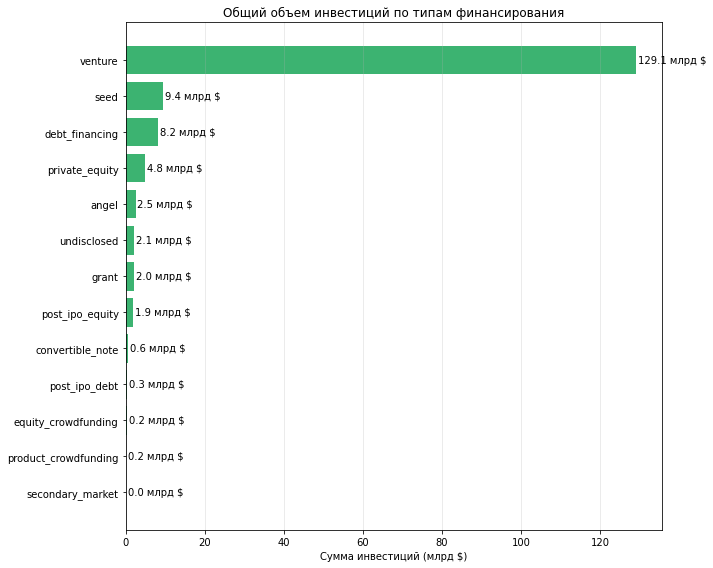


ТОП-3 ТИПА ФИНАНСИРОВАНИЯ:
1. venture: $129.09 млрд
2. seed: $9.43 млрд
3. debt_financing: $8.18 млрд


In [28]:
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# Считаем суммы
totals = investments_df[funding_types].sum().sort_values(ascending=True)  # сортируем по возрастанию для горизонтального графика

plt.figure(figsize=(10, 8))
plt.barh(totals.index, totals.values / 1e9, color='mediumseagreen')
plt.xlabel('Сумма инвестиций (млрд $)')
plt.title('Общий объем инвестиций по типам финансирования')
plt.grid(axis='x', alpha=0.3)

# Добавляем значения
for i, val in enumerate(totals.values):
    plt.text(val/1e9 + 0.5, i, f'{val/1e9:.1f} млрд $', va='center')

plt.tight_layout()
plt.show()

# Выводим топ-3
print("\nТОП-3 ТИПА ФИНАНСИРОВАНИЯ:")
for i, (idx, val) in enumerate(totals.sort_values(ascending=False).head(3).items()):
    print(f"{i+1}. {idx}: ${val/1e9:.2f} млрд")

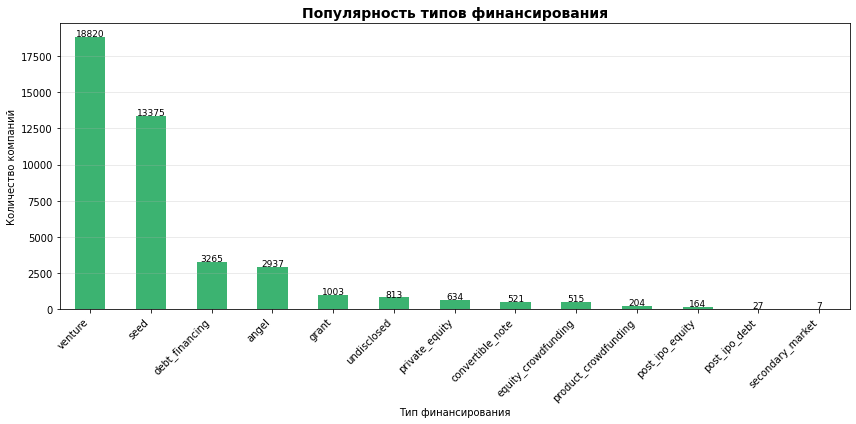


САМЫЙ ПОПУЛЯРНЫЙ ТИП: venture (18820 компаний)
ВТОРОЙ ПО ПОПУЛЯРНОСТИ: seed (13375 компаний)
ТРЕТИЙ ПО ПОПУЛЯРНОСТИ: debt_financing (3265 компаний)


In [29]:
# Простой вариант
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# Считаем популярность
popularity = (investments_df[funding_types] > 0).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
popularity.plot(kind='bar', color='mediumseagreen')
plt.title('Популярность типов финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Тип финансирования')
plt.ylabel('Количество компаний')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения над столбцами
for i, val in enumerate(popularity.values):
    plt.text(i, val + 50, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nСАМЫЙ ПОПУЛЯРНЫЙ ТИП:", popularity.index[0], f"({popularity.values[0]} компаний)")
print("ВТОРОЙ ПО ПОПУЛЯРНОСТИ:", popularity.index[1], f"({popularity.values[1]} компаний)")
print("ТРЕТИЙ ПО ПОПУЛЯРНОСТИ:", popularity.index[2], f"({popularity.values[2]} компаний)")

In [30]:
# Простой анализ
popularity = (investments_df[funding_types] > 0).sum()
volumes = investments_df[funding_types].sum() / 1e9
avg_check = volumes / popularity * 1000  # в миллионах на компанию

# Создаем DataFrame
analysis = pd.DataFrame({
    'компаний': popularity,
    'объем_млрд': volumes,
    'средний_чек_млн': avg_check
}).sort_values('компаний', ascending=False)

print(analysis.round(2))

# Находим аномальные комбинации
print("\nЧАСТО (более 5000 компаний), но МАЛО (средний чек < 10 млн):")
freq_small = analysis[(analysis['компаний'] > 5000) & (analysis['средний_чек_млн'] < 10)]
print(freq_small[['компаний', 'средний_чек_млн']])

print("\nРЕДКО (менее 500 компаний), но МНОГО (средний чек > 50 млн):")
rare_big = analysis[(analysis['компаний'] < 500) & (analysis['средний_чек_млн'] > 50)]
print(rare_big[['компаний', 'средний_чек_млн']])

                      компаний  объем_млрд  средний_чек_млн
venture                  18820  129.089996             6.86
seed                     13375    9.430000             0.71
debt_financing            3265    8.180000             2.50
angel                     2937    2.480000             0.84
grant                     1003    1.980000             1.97
undisclosed                813    2.100000             2.58
private_equity             634    4.840000             7.64
convertible_note           521    0.570000             1.09
equity_crowdfunding        515    0.240000             0.46
product_crowdfunding       204    0.190000             0.91
post_ipo_equity            164    1.950000            11.87
post_ipo_debt               27    0.290000            10.62
secondary_market             7    0.050000             6.47

ЧАСТО (более 5000 компаний), но МАЛО (средний чек < 10 млн):
         компаний  средний_чек_млн
venture     18820         6.859310
seed        13375         0.

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

СУММАРНЫЕ ВОЗВРАТЫ ПО ТИПАМ (в млн $)
venture                 40578.621094
debt_financing           4734.850098
private_equity           3587.330078
seed                     2382.239990
angel                    1509.229980
post_ipo_equity          1104.959961
undisclosed               730.880005
post_ipo_debt              91.029999
convertible_note           34.790001
secondary_market            5.200000
equity_crowdfunding         3.830000
product_crowdfunding        1.860000
grant                       0.000000
dtype: float32


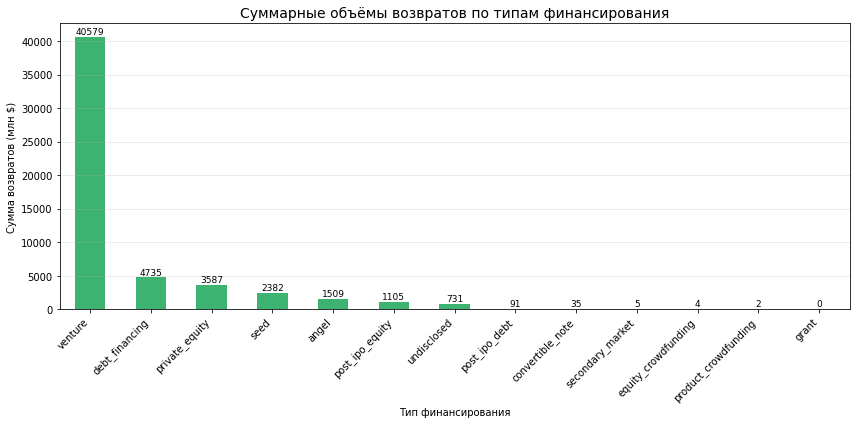

In [31]:
# Список типов финансирования (те же, что и в returns_df)
return_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# Считаем сумму возвратов по каждому типу за весь период
total_returns = returns_df[return_types].sum().sort_values(ascending=False)

print("СУММАРНЫЕ ВОЗВРАТЫ ПО ТИПАМ (в млн $)")
print(total_returns.round(2))

# Строим график
plt.figure(figsize=(12, 6))
total_returns.plot(kind='bar', color='mediumseagreen')
plt.title('Суммарные объёмы возвратов по типам финансирования', fontsize=14)
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма возвратов (млн $)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения над столбцами
for i, val in enumerate(total_returns.values):
    plt.text(i, val + max(total_returns.values)*0.01, f'{val:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

На основе анализа объёмов и популярности типов финансирования можно сделать следующие выводы:

1. **Абсолютное доминирование венчурного капитала**. Венчурное финансирование (venture) лидирует по всем показателям: оно привлекло 129 млрд (более 80% от общего объёма), использовалось 18 820 компаниями и при этом сохраняет относительно высокий средний чек — 6,86 млн. Это основной драйвер рынка.

2. **Посевное финансирование — самый доступный инструмент**. Seed занимает второе место по популярности (13 375 компаний) и объёму (9,43 млрд), но характеризуется самым низким средним чеком среди топ-сегментов — всего 0,71 млн. Это типичный инструмент для стартапов на ранних стадиях.

3. **Долговое финансирование — значимый, но нишевый инструмент**. Debt_financing замыкает тройку лидеров как по объёму (8,18 млрд), так и по популярности (3 265 компаний). Средний чек 2,5 млн указывает на его использование более зрелыми компаниями.

4. **Часто используемые типы с небольшими чеками**. В категорию «часто, но мало» попадают venture и seed. При этом venture, несмотря на попадание в эту группу, всё же имеет средний чек почти в 10 раз выше, чем у seed, что отражает его роль на более поздних стадиях.

5. **Редкие, но крупные типы финансирования**. Типов, которые используются редко (менее 500 компаний), но при этом имеют средний чек выше 50 млн, не обнаружено. Ближе всего к этой категории post_ipo_equity (164 компании, средний чек 11,87 млн) и post_ipo_debt (27 компаний, 10,62 млн), но их чеки всё ещё ниже порога в 50 млн.

6. **Соотношение инвестиций и возвратов**. Венчурный капитал не только лидирует по объёму привлечённых средств (129 млрд), но и генерирует наибольший объём возвратов — 40,6 млрд. Это подтверждает его эффективность как инвестиционного инструмента. Для сравнения, посевное финансирование при объёме 9,4 млрд вернуло только 2,4 млрд, что указывает на его высокорисковую природу.

Таким образом, венчурное финансирование является безусловным лидером рынка, сочетая масштаб, популярность и высокую отдачу. Посевные инвестиции выполняют важную роль «входного билета» для стартапов, но характеризуются низкой эффективностью возвратов. Долговое финансирование занимает устойчивую нишу среднего сегмента.

## Анализ динамики

### Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).


На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [32]:
# Рассчитываем средний объём раунда для каждой компании
investments_df['avg_round_size'] = investments_df['funding_total_usd'] / investments_df['rounds_count']

# Проверяем результат
print("СРЕДНИЙ ОБЪЁМ РАУНДА ПО КОМПАНИЯМ\n")
print(f"Всего компаний: {len(investments_df)}")
print(f"Средний чек на раунд по всем компаниям: ${investments_df['avg_round_size'].mean()/1e6:.2f} млн")
print(f"Медианный чек на раунд: ${investments_df['avg_round_size'].median()/1e6:.2f} млн")

# Смотрим первые несколько компаний
print("\nПримеры по компаниям:")
sample = investments_df[['name', 'rounds_count', 'funding_total_usd', 'avg_round_size']].head(10)
sample['funding_total_usd_m'] = sample['funding_total_usd'] / 1e6
sample['avg_round_size_m'] = sample['avg_round_size'] / 1e6
print(sample[['name', 'rounds_count', 'funding_total_usd_m', 'avg_round_size_m']].round(2))

# Базовая статистика
print("\nСтатистика по среднему размеру раунда (в млн $):")
print(investments_df['avg_round_size'].describe().apply(lambda x: x/1e6).round(2))

СРЕДНИЙ ОБЪЁМ РАУНДА ПО КОМПАНИЯМ

Всего компаний: 35588
Средний чек на раунд по всем компаниям: $2.79 млн
Медианный чек на раунд: $1.00 млн

Примеры по компаниям:
                               name  rounds_count  funding_total_usd_m  \
1       university of new brunswick           1.0                 2.00   
2                            dupont           1.0                 9.00   
3            university of michigan           3.0                 7.70   
4   case western reserve university           1.0                 0.54   
7                   duke university           1.0                 8.70   
9                            wegame           2.0                 3.50   
11                     mayne pharma           1.0                 2.70   
12                          siemens           1.0                 8.90   
16        michigan state university           1.0                 3.90   
18           wilberforce university           1.0                 2.00   

    avg_round_size_m 

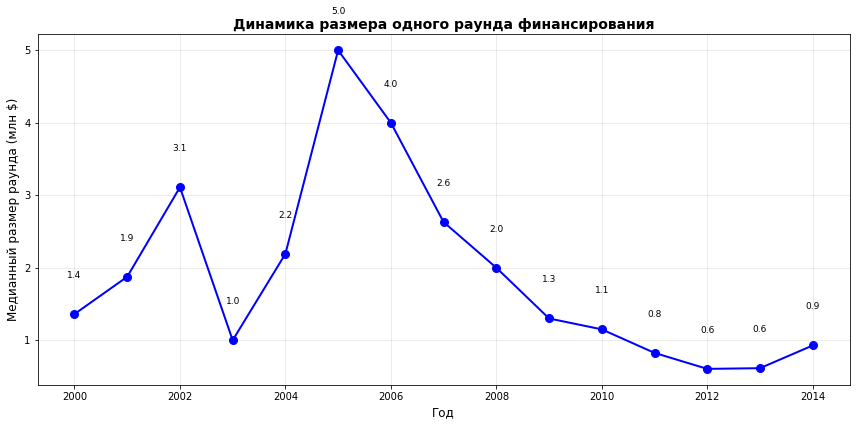

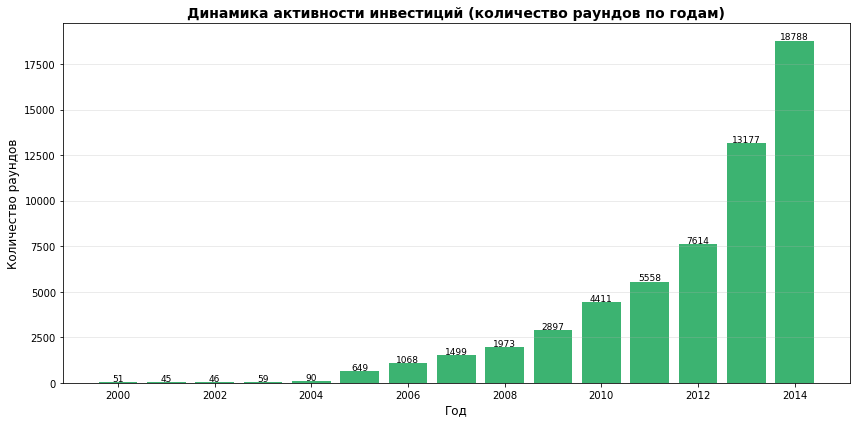

In [33]:
# Подготавливаем данные
investments_df['year'] = investments_df['last_funding_date'].dt.year
yearly_stats = investments_df.groupby('year').agg(
    avg_round_size=('avg_round_size', 'median'),  # используем медиану как более устойчивую
    total_rounds=('rounds_count', 'sum')
).reset_index()

# Фильтруем по годам (от 1995 до 2014)
yearly_stats = yearly_stats[(yearly_stats['year'] >= 1995) & (yearly_stats['year'] <= 2014)]

# График 1: Динамика размера раунда
plt.figure(figsize=(12, 6))
plt.plot(yearly_stats['year'], yearly_stats['avg_round_size']/1e6, 
         marker='o', color='blue', linewidth=2, markersize=8)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Медианный размер раунда (млн $)', fontsize=12)
plt.title('Динамика размера одного раунда финансирования', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Добавляем значения над точками
for i, row in yearly_stats.iterrows():
    plt.text(row['year'], row['avg_round_size']/1e6 + 0.5, 
             f"{row['avg_round_size']/1e6:.1f}", 
             ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# График 2: Динамика количества раундов
plt.figure(figsize=(12, 6))
plt.bar(yearly_stats['year'], yearly_stats['total_rounds'], 
        color='mediumseagreen')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество раундов', fontsize=12)
plt.title('Динамика активности инвестиций (количество раундов по годам)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения над столбцами
for i, row in yearly_stats.iterrows():
    plt.text(row['year'], row['total_rounds'] + 50, 
             f"{int(row['total_rounds'])}", 
             ha='center', fontsize=9)

plt.tight_layout()
plt.show()

1. Максимальный размер раунда

Типичный размер средств в одном раунде был максимальным в 2005 году.
Медианный размер раунда: 5.00 млн.

Топ-3 года по размеру раундов:
- 2005: 5.00 млн
- 2006: 4.00 млн
- 2002: 3.11 млн

2. Тенденции 2014 года

2014 год:
- Количество раундов: 18788
- Медианный размер раунда: 0.93 млн

По сравнению с 2013 годом:
- Количество раундов: +42.6% (13177 → 18788)
- Размер раунда: +51.0% (0.61 млн → 0.93 млн)

Рынок рос по обоим направлениям: больше раундов и крупнее чеки

### Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматрим только массовые сегменты, а средние и нишевые исключим.

На основе графика сделаем вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [34]:
investments_df['year'] = investments_df['last_funding_date'].dt.year

# Сводная таблица
pivot = pd.pivot_table(
    investments_df,
    values='funding_total_usd',
    index='market',
    columns='year',
    aggfunc='sum',
    fill_value=0
)

# Отбираем сегменты с ростом в 2014
if 2013 in pivot.columns and 2014 in pivot.columns:
    growing = pivot[(pivot[2014] > pivot[2013]) & (pivot[2013] > 0)].copy()
    growing['growth'] = ((growing[2014] / growing[2013] - 1) * 100).round(1)
    growing = growing.sort_values('growth', ascending=False)
    
    print("СЕГМЕНТЫ С РОСТОМ В 2014 ГОДУ\n")
    print(growing[[2013, 2014, 'growth']].round(2))
    
    print(f"\nВсего сегментов с ростом: {len(growing)}")

СЕГМЕНТЫ С РОСТОМ В 2014 ГОДУ

year                        2013         2014  growth
market                                               
entertainment           27461143    141562216   415.5
niche                  179153772    919076873   413.0
apps                    24477667     96265838   293.3
sports                  22394480     78558458   250.8
medical                 70852502    225499370   218.3
startups                18249785     52451206   187.4
news                    41872749    117625778   180.9
real estate             72967268    192572930   163.9
unknown category       252224426    657182312   160.6
web hosting            234724290    605996417   158.2
saas                    66933785    172178300   157.2
messaging               30943659     79564979   157.1
marketplaces            28245202     68575670   142.8
internet                76318317    182523435   139.2
social network media    26041170     55460162   113.0
security               425855847    898920434   111

Найдено массовых сегментов с ростом: 44


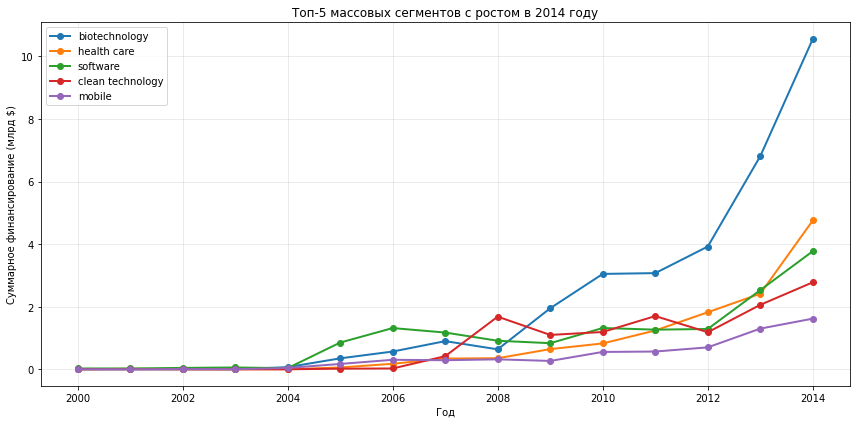


Топ-5 сегментов (млрд $):
year              2013   2014
market                       
biotechnology     6.82  10.56
health care       2.42   4.76
software          2.53   3.78
clean technology  2.06   2.78
mobile            1.30   1.62


In [35]:
# Подготавливаем данные
investments_df['year'] = investments_df['last_funding_date'].dt.year

# Создаем сводную таблицу: сумма финансирования по сегментам и годам
pivot = pd.pivot_table(
    investments_df,
    values='funding_total_usd',
    index='market',
    columns='year',
    aggfunc='sum',
    fill_value=0
)

# Оставляем только массовые сегменты (все, кроме mid и niche)
mass_segments = pivot[~pivot.index.isin(['mid', 'niche'])].copy()

# Отбираем те, что выросли в 2014 году по сравнению с 2013
if 2013 in mass_segments.columns and 2014 in mass_segments.columns:
    growing = mass_segments[(mass_segments[2014] > mass_segments[2013]) & (mass_segments[2013] > 0)]
    
    # Переводим в миллиарды
    growing = growing / 1e9
    
    print(f"Найдено массовых сегментов с ростом: {len(growing)}")
    
    # Берем топ-5 по объему в 2014 году
    top_5 = growing.sort_values(2014, ascending=False).head(5)
    
    # Строим график
    plt.figure(figsize=(12, 6))
    
    for segment in top_5.index:
        # Берем данные с 2000 по 2014 год
        years = [y for y in range(2000, 2015) if y in growing.columns]
        values = [top_5.loc[segment, y] for y in years]
        plt.plot(years, values, marker='o', linewidth=2, label=segment)
    
    plt.xlabel('Год')
    plt.ylabel('Суммарное финансирование (млрд $)')
    plt.title('Топ-5 массовых сегментов с ростом в 2014 году')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(range(2000, 2015, 2))
    
    plt.tight_layout()
    plt.show()
    
    # Показываем цифры
    print("\nТоп-5 сегментов (млрд $):")
    print(top_5[[2013, 2014]].round(2))
else:
    print("Нет данных за 2013 или 2014 год")

Наиболее быстрый рост демонстрирует Health Care, практически удвоившись за год (+96.7%). Наиболее уверенный и масштабный рост показывает Biotechnology, который не только лидирует по абсолютному приросту (+3.74 млрд), но и сохраняет высокие темпы (+54.8%), оставаясь крупнейшим сегментом.

### Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

In [36]:
# Проверяем формат годов
print("ПРОВЕРКА ФОРМАТА ГОДОВ\n")

# Годы в инвестициях
inv_years = sorted(investments_df['mid_funding_date'].dt.year.unique())
print(f"Годы в инвестициях: {inv_years}")
print(f"Тип: {type(inv_years[0])}")

# Годы в возвратах
print(f"\nГоды в возвратах ДО преобразования:")
print(f"Индекс: {returns_df.index[:5].tolist()}")
print(f"Тип индекса: {type(returns_df.index[0])}")

# ПРЕОБРАЗУЕМ ИНДЕКС В ЦЕЛЫЕ ЧИСЛА (ГОДА)
returns_df.index = returns_df.index.year
print(f"\nГоды в возвратах ПОСЛЕ преобразования:")
print(f"Индекс: {returns_df.index[:5].tolist()}")
print(f"Тип индекса: {type(returns_df.index[0])}")

# Теперь берем уникальные года
ret_years = sorted(returns_df.index.unique())
print(f"\nГоды в возвратах (числа): {ret_years}")

# Общие годы
common = set(inv_years) & set(ret_years)
print(f"\nОбщие годы: {sorted(common)}")

# Расчет нормированных значений
if len(common) > 0:
    print(f"\nНашлись общие года! Выполняем расчет...")
    
    # Группируем инвестиции по годам
    investments_by_year = investments_df.groupby(investments_df['mid_funding_date'].dt.year)[
        ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
         'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
         'post_ipo_debt', 'secondary_market', 'product_crowdfunding']
    ].sum()
    
    # Возвраты с преобразованным индексом
    returns_by_year = returns_df.copy()
    
    # Переводим возвраты из миллионов в доллары
    returns_by_year = returns_by_year * 1e6
    
    # Создаем таблицу результатов
    result = pd.DataFrame(index=sorted(common), columns=investments_by_year.columns)
    epsilon = 1e-60
    
    for year in sorted(common):
        for col in result.columns:
            inv = investments_by_year.loc[year, col]
            ret = returns_by_year.loc[year, col]
            
            if inv > 0:
                ratio = ret / (inv + epsilon)
                if ratio > 3:  # аномалии > 300%
                    ratio = pd.NA
            else:
                ratio = pd.NA
                
            result.loc[year, col] = ratio
    
    # Выводим результат
    print("\nНОРМИРОВАННЫЕ ЗНАЧЕНИЯ ВОЗВРАТА\n")
    print(result.round(4))
    
    # Показываем непустые значения
    print("\nТОЛЬКО НЕПУСТЫЕ ЗНАЧЕНИЯ\n")
    non_empty = result.dropna(how='all', axis=0).dropna(how='all', axis=1)
    if not non_empty.empty:
        print(non_empty.round(4))
    else:
        print("Все значения NaN")
else:
    print("\nНет общих годов для анализа.")

ПРОВЕРКА ФОРМАТА ГОДОВ

Годы в инвестициях: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
Тип: <class 'numpy.int64'>

Годы в возвратах ДО преобразования:
Индекс: [Timestamp('2000-01-01 00:00:00'), Timestamp('2001-01-01 00:00:00'), Timestamp('2002-01-01 00:00:00'), Timestamp('2003-01-01 00:00:00'), Timestamp('2004-01-01 00:00:00')]
Тип индекса: <class 'pandas._libs.tslibs.timestamps.Timestamp'>

Годы в возвратах ПОСЛЕ преобразования:
Индекс: [2000, 2001, 2002, 2003, 2004]
Тип индекса: <class 'numpy.int64'>

Годы в возвратах (числа): [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]

Общие годы: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]

Нашлись общие года! Выполняем расчет...

НОРМИРОВАННЫЕ ЗНАЧЕНИЯ ВОЗВРАТА

          seed   venture equity_crowdfunding undisclosed convertible_note  \
2000  0.996471  0.168922                <NA>    0.697042             <

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

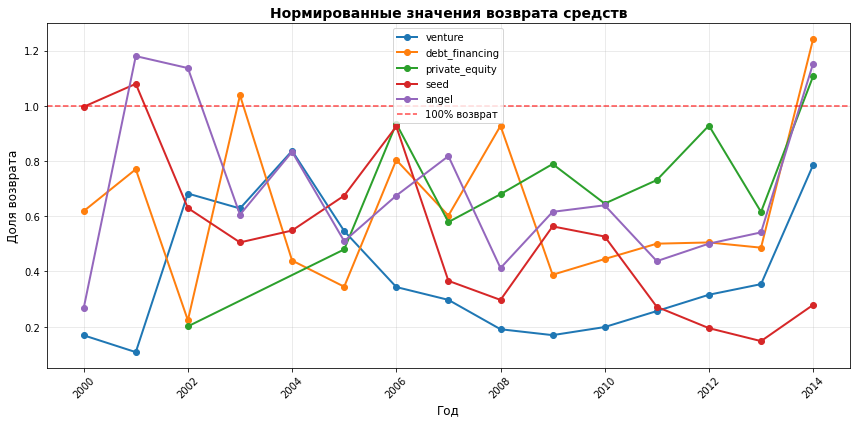

In [37]:
# Выбираем нужные типы финансирования
selected = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

plt.figure(figsize=(12, 6))

# Для каждого типа строим линию
for col in selected:
    if col in result.columns:
        # Убираем пропуски (dropna) и строим график только по точкам с данными
        data = result[col].dropna()
        if len(data) > 0:  # проверяем, что есть данные
            plt.plot(data.index, data.values, marker='o', linewidth=2, label=col)

# Добавляем горизонтальную линию на уровне 1 (100% возврат)
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='100% возврат')

# Настройки графика
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля возврата', fontsize=12)
plt.title('Нормированные значения возврата средств', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [38]:
# Выводим значения для анализа
selected = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

print("ЗНАЧЕНИЯ ДОЛИ ВОЗВРАТА ПО ГОДАМ\n")

for col in selected:
    if col in result.columns:
        data = result[col].dropna()
        if len(data) > 0:
            print(f"\n{col}:")
            for year, val in data.items():
                print(f"  {year}: {val:.4f} ({val*100:.1f}%)")
            
            # Считаем рост от первого к последнему году
            first_year = data.index[0]
            last_year = data.index[-1]
            first_val = data.iloc[0]
            last_val = data.iloc[-1]
            
            if first_val > 0:
                growth = ((last_val - first_val) / first_val) * 100
                print(f"  Рост за период: {growth:+.1f}%")
            else:
                print(f"  Рост за период: {last_val:.4f} (от нуля)")
            
            # Считаем волатильность (стандартное отклонение)
            volatility = data.std()
            print(f"  Волатильность: {volatility:.4f}")    

ЗНАЧЕНИЯ ДОЛИ ВОЗВРАТА ПО ГОДАМ


venture:
  2000: 0.1689 (16.9%)
  2001: 0.1080 (10.8%)
  2002: 0.6823 (68.2%)
  2003: 0.6283 (62.8%)
  2004: 0.8370 (83.7%)
  2005: 0.5466 (54.7%)
  2006: 0.3437 (34.4%)
  2007: 0.2972 (29.7%)
  2008: 0.1909 (19.1%)
  2009: 0.1695 (17.0%)
  2010: 0.1988 (19.9%)
  2011: 0.2567 (25.7%)
  2012: 0.3158 (31.6%)
  2013: 0.3542 (35.4%)
  2014: 0.7856 (78.6%)
  Рост за период: +365.1%
  Волатильность: 0.2408

debt_financing:
  2000: 0.6186 (61.9%)
  2001: 0.7703 (77.0%)
  2002: 0.2234 (22.3%)
  2003: 1.0381 (103.8%)
  2004: 0.4397 (44.0%)
  2005: 0.3450 (34.5%)
  2006: 0.8038 (80.4%)
  2007: 0.6025 (60.2%)
  2008: 0.9275 (92.7%)
  2009: 0.3882 (38.8%)
  2010: 0.4451 (44.5%)
  2011: 0.5008 (50.1%)
  2012: 0.5052 (50.5%)
  2013: 0.4863 (48.6%)
  2014: 1.2417 (124.2%)
  Рост за период: +100.7%
  Волатильность: 0.2813

private_equity:
  2002: 0.2013 (20.1%)
  2005: 0.4800 (48.0%)
  2006: 0.9355 (93.5%)
  2007: 0.5791 (57.9%)
  2008: 0.6799 (68.0%)
  2009: 0.7892 (

Наибольшую устойчивость роста демонстрируют private_equity и venture. private_equity показывает стабильный восходящий тренд с 2005 года, достигнув 110.7% возврата в 2014 году при росте за период +449.9% и низкой волатильности 0.2458. venture имеет самую низкую волатильность (0.2408) и уверенный рост с 2009 года, завершив 2014 год с показателем 78.6% (+365.1% за период). В отличие от них, seed демонстрирует устойчивое падение (-72% за период) и не рекомендуется для инвестиций с точки зрения возврата средств.


## Итоговый вывод и рекомендации

Представим, что на календаре 2015 год. Опираясь на результаты анализа, дадим рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведем итоги проекта:
* какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



### Рекомендации для инвестиций в 2015 году

1.  Отрасль: Biotechnology. Это наиболее перспективный сектор. В 2014 году он привлек рекордные 10.56 млрд, что более чем вдвое превышает показатели ближайшего конкурента (Health Care). При таком масштабе отрасль продолжает уверенно расти: прирост составил +54.8% и 3.74 млрд за год, что является лучшим абсолютным показателем на рынке.

2.  Тип финансирования: Venture (венчурные инвестиции). Это оптимальный инструмент для работы в выбранном секторе. Он доминирует на рынке с общим объемом 129 млрд и является самым популярным (использован 18 820 компаниями). Ключевой финансовый аргумент — устойчивая положительная динамика возврата инвестиций: с 2009 года доля возврата неуклонно растет и в 2014 году достигла 78.6% при самой низкой волатильности среди всех типов финансирования.

### Итоги проекта

1. Выполненные шаги

В ходе исследования были последовательно реализованы все этапы анализа данных:

- Загрузка и первичный анализ: изучена структура данных, выявлены проблемы с типами, пропусками и форматами (например, funding_total_usd в виде строки с разделителями).

- Предобработка: приведены типы данных, обработаны пропуски (заполнение заглушками, расчет mid_funding_date), удалены дубликаты и строки без информации о финансировании. В результате очистки потеряно 24.7% данных, оставлено 40 907 записей для анализа.

- Инжиниринг признаков: компании разделены на 3 группы по срокам финансирования (единичное, до года, более года); рынки классифицированы на массовые (>120 компаний), средние (35-120) и нишевые (<35). Массовые сегменты (49 шт.) охватывают 88.6% всех компаний.

- Работа с выбросами: выбросы определены методом IQR отдельно для каждого сегмента и удалены (5 244 компании, 12.8% данных). Также оставлены только годы с активностью ≥50 раундов.

- Анализ типов финансирования: изучены объемы и популярность различных типов инвестиций, а также динамика возвратов по ним.

- Анализ динамики: исследованы тренды по годам: размер раундов, количество сделок, рост сегментов и доля возврата средств.

2. Ключевые выводы

- Рынок консолидируется вокруг лидеров: массовые сегменты (49 шт.) занимают почти 90% рынка. Наиболее перспективными выглядят Biotechnology (лидер по объему и уверенному росту) и Health Care (лидер по темпам роста в 2014 году).

- Венчурный капитал — основной драйвер: самый крупный и популярный тип финансирования, демонстрирующий наиболее устойчивый рост доли возврата инвестиций. Посевное финансирование (seed), напротив, показывает неуклонное падение эффективности.

- Рынок активно рос в 2014 году: наблюдался синхронный рост как количества раундов (+42.6% к 2013), так и их среднего размера (+51%), что указывает на "бум" инвестиционной активности.

- Выводы согласованы: рекомендация инвестировать в Biotechnology с использованием venture капитала логично вытекает из всех этапов анализа: это крупнейший растущий сегмент, финансируемый через самый ликвидный и эффективный инструмент.

3. Согласованность и сомнения

Выводы хорошо согласуются между собой и не противоречат друг другу. Анализ разных аспектов (объемы рынка, популярность инструментов, динамика возвратов) указывает на одни и те же точки роста — Biotechnology и Venture.

Что вызывает сомнения (или требует дальнейшего изучения):

- Сегмент "Unknown Category" занимает 4-е место по популярности (2 503 компании) и входит в топ-10 по доле аномалий. Это огромный пласт неклассифицированных данных, который может скрывать как перспективные ниши, так и "пустышки", искажая общую картину.

- Объединенные средние (mid) и нишевые (niche) сегменты попали в топ-10 по доле компаний с аномальным финансированием (14.5% и 15.9%). Это говорит о том, что на этих рынках либо высокая неопределенность, либо они могут быть источниками будущих "единорогов" с нетипично высокими чеками.

- Почти по всем типам финансирования в 2014 году произошел резкий скачок доли возврата (например, venture вырос с 35% до 78%). Это коррелирует с общим ростом рынка, но такие резкие изменения требуют проверки: это устойчивый тренд или разовая коррекция, связанная с выходом на IPO нескольких крупных игроков? Данных за 2015 год пока нет, чтобы это подтвердить.